# Imaging Performance Comparison (Flare)
This notebook loops over different noise levels and calibration errors to generate, corrupt, image, and compare solar flare datasets.

In [64]:
import fasr_solar_simul as fss
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from scipy.special import j1
from scipy.constants import c
import os
import glob
from casatasks import tclean, applycal, clearcal
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from astropy.time import Time
from sunpy import coordinates

# Speed of light in m/s
C_LIGHT = c
import matplotlib
%matplotlib inline

In [65]:
from importlib import reload

reload(fss)
target = 'flare'
figsubfolder = 'figs/'
model_dir = r'../fasr_sim/skymodels/eruptive_flare'

# Imaging Performance Comparison
looping over different noise levels and calibration errors to generate, corrupt, image, and compare

## Set up the simulation

In [67]:
# List of all available frequencies in GHz
freq_list = ['05.15GHz']  # flare model filenames use this frequency format
imsizes = [512, 512, 1024, 2048, 4096]
cells = ['4.8arcsec', '4.8arcsec', '2.4arcsec', '1.2arcsec', '0.6arcsec']
scales = [[0, 5, 10, 50], [0, 4, 10, 40], [0, 6, 20, 80], [0, 5, 10, 40, 160], [0, 10, 40, 80, 320]]

selection = [0]
# Revise freq_list, imsizes, cells, and scales using the selection
freq_list = [freq_list[i] for i in selection]
imsizes = [imsizes[i] for i in selection]
cells = [cells[i] for i in selection]
scales = [scales[i] for i in selection]


# List of configurations
project = 'FASR'
#config_files = ['fasr_Log_Spiral-168.cfg', 'fasr-a_random_spiral_hybrid_120.cfg']
config_files = ['fasr-a_random_spiral_hybrid_120.cfg']

## Antenna temperature noise levels
tsys_all = [5000.]

## Define the fractional gain errors tuples: (phase and amplitude)
# 6 degrees (or 1.7% of phase error is equivalent to 10% of amplitude error )
#cal_errors = [(0., 0.), (0.017, 0.1)]
cal_errors = [(0., 0.)]

# Define channel width and integration time
channel_width_mhz = 24. # channel width in MHz
integration_time = 1. # Time per integration in seconds
duration = 1. # Total imaging duration in seconds

# Reference timestamp for the observation series
reftime_obj = fss.get_local_noon_utc(config_files[0], datetime(2017, 9, 10, 15, 45, 0))
reftime = reftime_obj.strftime('%Y-%m-%dT%H:%M:%S')  # flare simulation reference time
solar_radius_asec = coordinates.sun.angular_radius(reftime).value

# Flags to control overwriting existing data products
overwrite_ms   = False  # Overwrite measurement set?
overwrite_im   = False  # Overwrite image products?
overwrite_plot = True  # Overwrite existing plots?

weighting = 'uniform'
# Deconvolution algorithm choice
deconvolver = 'hogbom'
niter = 10000

deconvolver = 'multiscale'
niter = 10000
 
# Global plotting crop control used by all comparison plots
plot_crop_fraction = (0.0, 1.0)


# Centralized tclean phase center used by all imaging calls
## this phacenter is read from full disk image. 
## The ms may has some issue that hf.calc_phasecenter_from_solxy returns a phase center that is a few arcminutes off.
phasecenter_tclean = 'J2000 11h14m17s +4d44m48s' 
# phasecenter_tclean = ''



'get_local_noon_utc' completed at 2026-02-25 14:27:43; runtime: 0.06 seconds


## Imaging Test: Hybrid 120 vs +10 Remote Antennas (2-10 km)
This section runs a small imaging test and compares:
- Base: `fasr-a_random_spiral_hybrid_120.cfg`
- Remote: `fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg`

It uses the same sky model and imaging parameters for both, so differences are driven by UV-coverage / weighting.

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale.image: 2.577e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale.image (corners): 1.724e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.563e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.849e+05 K
Plotting both panels with shared vmin=2.577e+05 K, vmax=2.577e+08 K

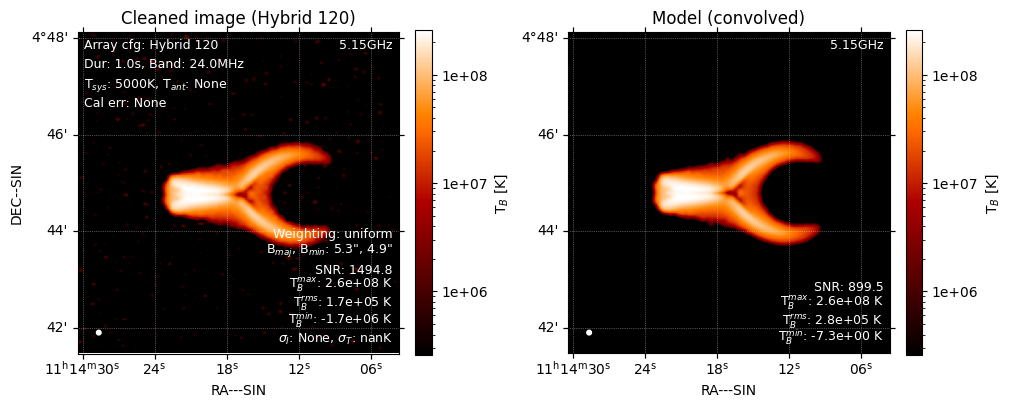

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I.im.jpg
Image1 map obstime: 2017-09-10T19:34:33.660669, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale.image: 2.662e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale.image 

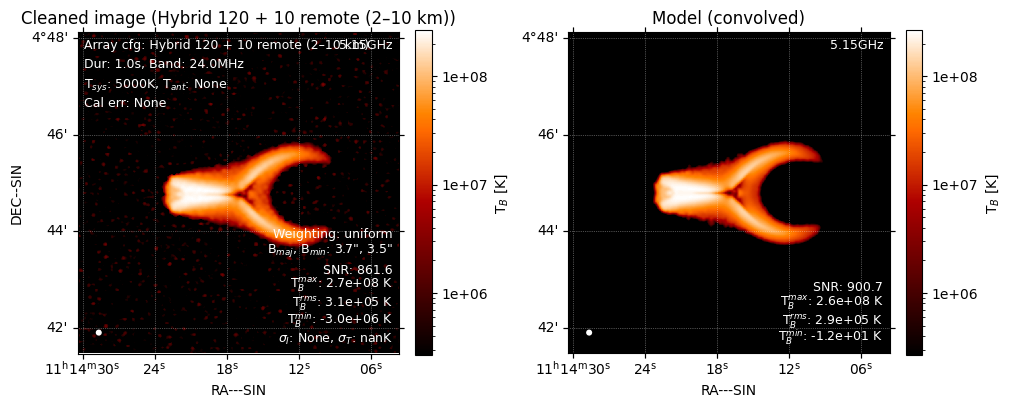

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I.im.jpg


In [68]:
phasecenter_tclean = globals().get('phasecenter_tclean', 'J2000 11h14m13.36s +30d04m44s')
reload(fss)
import os
import sys
_suncasa_src = os.path.expanduser('~/Dropbox/PycharmProjects/suncasa/suncasa-src')
if _suncasa_src not in sys.path:
    sys.path.append(_suncasa_src)
from suncasa.utils import helioimage2fits as hf
reload(hf)

# --- Configs to compare ---
base_cfg = 'fasr-a_random_spiral_hybrid_120.cfg'
remote_cfg = 'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg'

# --- Quick test parameters (edit as needed) ---
freqstr = '05.15GHz'
solar_model = f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits'

# imaging grid (try smaller cell for super-resolution experiments)
imsize = 800
cell = '0.5arcsec'
image_rms_corner_size = 100 ## in pixels (n by n) near the corner. This only applies to tclean images, not the model image.
vmax = 100.
# imsize = 2560
# cell = '1.0arcsec'
scales = [0, 6, 20]

# noise / integration
tsys = 5000.
channel_width_mhz = 24.
integration_time = 1.
duration = 1.

# flare-centered phasecenter in solar X/Y arcsec
flare_xycen = (1050, -140)

# calibration errors (set to 0 for this test)
phaerr = 0.
amperr = 0.

# baseline CASA timestamp
reftime_casa = Time(reftime).strftime('%Y/%m/%d/%H:%M:%S')

# Make sure output dirs exist
figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
caltbdir = os.path.join(project, 'caltbs')
os.makedirs(caltbdir, exist_ok=True)

configs = [base_cfg, remote_cfg]
remote_cfg_base = os.path.basename(remote_cfg).replace('.cfg', '')
remote_parts = remote_cfg_base.split('_')
remote_count = next((p.replace('remote', '') for p in remote_parts if p.startswith('remote')), '?')
remote_range = next((p[1:] for p in remote_parts if p.startswith('r') and p.endswith('km') and '-' in p), '?-?km')
remote_range_label = remote_range.replace('km', ' km').replace('-', '–')
remote_label = f'Hybrid 120 + {remote_count} remote ({remote_range_label})'
labels = ['Hybrid 120', remote_label]
# weightings = ['natural', 'uniform']
weightings = ['uniform']

# Optional: overwrite only +10 remote images (leave Hybrid 120 images untouched)
overwrite_remote_im = False  # set True to re-run only remote_cfg tclean images

for weighting in weightings:
    ims = []
    for config_file in configs:
        msname = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, config_file, tsys)
        msfile = f'{msname}.ms'

        if (not os.path.exists(msfile)) or overwrite_ms:
            if os.path.exists(msfile) and overwrite_ms:
                os.system('rm -rf ' + msfile)
            print('Start generating ms:', msfile)
            msfile = fss.generate_ms(
                config_file, solar_model, reftime_casa, freqstr,
                integration_time=integration_time, duration=duration,
                channel_width_mhz=channel_width_mhz,
                msname=msfile, tsys=tsys, usehourangle=True
            )

        # Make an image name that includes cfg + weighting
        imname = f'{msname}_{weighting}_{deconvolver}'
        # phasecenter, _ = hf.calc_phasecenter_from_solxy(msfile, xycen=flare_xycen, usemsphacenter=True, verbose=True)
        # print(f'Using centralized phase center for {imname}: {phasecenter}')
        is_remote_cfg = (config_file == remote_cfg)
        overwrite_this_image = overwrite_im or (overwrite_remote_im and is_remote_cfg)
        if os.path.exists(f'{imname}.image') and overwrite_this_image:
            for j in ['.image', '.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                os.system(f'rm -rf {imname}{j}')

        if not os.path.exists(f'{imname}.image'):
            print('Imaging:', imname)
            tclean(
                vis=msfile, imagename=imname,
                datacolumn='data',
                specmode='mfs',
                deconvolver=deconvolver, scales=scales,
                gain=0.2, cycleniter=200, minpsffraction=0.1, pblimit=0.01,
                imsize=imsize, cell=cell,
                phasecenter=phasecenter_tclean,
                weighting=weighting,
                niter=niter,
                interactive=False
            )
            for j in ['.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                os.system(f'rm -rf {imname}{j}')

        ims.append(imname + '.image')

    # Compare each config against the flare model with the shared plotting utility
    model_path = os.path.join(project, 'msfiles', target, os.path.basename(solar_model.replace('.fits', '.im')))
    image_meta_common = {
        'freq': freqstr,
        'tsys': f'{tsys:.0f}K',
        'tant': None,
        'sigma_jy': None,
        'cal_error': None,
        'duration': f'{duration}s',
        'bandwidth': f'{channel_width_mhz}MHz',
    }
    cfg_display_names = [os.path.basename(cfg) for cfg in configs]

    for idx_cfg, im_path in enumerate(ims):
        fig_compare, axs_compare = fss.plot_two_casa_images_with_convolution_sunpy(
            im_path,
            model_path,
            crop_fraction=globals().get('plot_crop_fraction', (0.0, 1.0)),
            reftime=reftime,
            figsize=(10, 4),
            image_meta={
                **image_meta_common,
                'title': [f'Cleaned image ({labels[idx_cfg]})', 'Model (convolved)'],
                'array_config': cfg_display_names[idx_cfg],
                'imaging_weighting': weighting,
            },
            cmap='hinodexrt',
            vmax=vmax,
            vmin=0.1,            
            conv_tag=f'.compare_{weighting}_{idx_cfg}',
            overwrite_conv=True,
            rms_mask_radius=1.2,
            image_rms_corner_size=image_rms_corner_size,
            coord_frame='radec',
            # hpc_reference_xy=(0, 0),
            match_fov=True,
            align_model_time_to_image=True,
            north_up=False,
            apply_hpc_p_angle=False,
            anchor_model_wcs_to_image=True,
            use_reftime_for_hpc=True,
            )
        plt.show()

        figname = os.path.join(
            figdir,
            f"fig-{os.path.basename(im_path).replace('.image', '')}_vs_{os.path.basename(model_path)}.jpg"
        )
        if os.path.exists(figname) and overwrite_plot:
            os.system('rm -rf ' + figname)
        if not os.path.exists(figname):
            fig_compare.savefig(figname, dpi=200)
            print('Saved figure:', figname)


In [19]:
pwd

'/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul'

In [20]:
im_path,msfile,imname

('FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_hogbom.image',
 'FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K.ms',
 'FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uniform_hogbom')

## Super-Resolution / Long-Baseline Emphasis Options
With only a small number of remote antennas, the very long baselines are sparse. Even `uniform` weighting may not emphasize them enough. Below are two practical approaches that can push resolution beyond what uniform weighting gives.

1) **UV-range split + combine**: image long baselines only (high-res) and short baselines only (low-res), then combine in the image domain (e.g., `feather`).
2) **Manual weight boost**: multiply the MS `WEIGHT` / `SIGMA` by a function of UV-distance to upweight long baselines more strongly than uniform weighting.

Notes:
- Both methods increase noise in the final image and can create ringing if the long-baseline PSF sidelobes are high.
- Multi-scale deconvolution and tighter clean masks help stability.


In [71]:
# from math import sqrt
# import os
# import sys
# import glob
# import shutil
# _suncasa_src = os.path.expanduser('~/Dropbox/PycharmProjects/suncasa/suncasa-src')
# if _suncasa_src not in sys.path:
#     sys.path.append(_suncasa_src)
# from suncasa.utils import helioimage2fits as hf


# # Helper: parse CASA freq strings like '5GHz' or '1.00GHz' -> Hz
# def _freqstr_to_hz(freqstr):
#     s = freqstr.strip()
#     if s.lower().endswith('ghz'):
#         return float(s[:-3]) * 1e9
#     if s.lower().endswith('mhz'):
#         return float(s[:-3]) * 1e6
#     if s.lower().endswith('khz'):
#         return float(s[:-3]) * 1e3
#     if s.lower().endswith('hz'):
#         return float(s[:-2])
#     raise ValueError(f'Unrecognized freq string: {freqstr}')

# imsize = 800
# cell = '0.5arcsec'
# scales = [0, 6, 20]
# duration = 1.
# integration_time = 1.
# channel_width_mhz = 24.
# tsys = 5000.

# # Overwrite controls for super-resolution products.
# overwrite_superres_remote = True
# overwrite_superres_hybrid = True
# overwrite_boost_ms_remote = True
# overwrite_boost_ms_hybrid = True


# def _remove_path(path):
#     if os.path.isdir(path):
#         shutil.rmtree(path)
#     elif os.path.exists(path):
#         os.remove(path)

# def _clear_casa_imagename(imagename_base):
#     for p in glob.glob(imagename_base + '.*'):
#         _remove_path(p)

# # Tip: CASA also supports weighting='superuniform' (often more aggressive than 'uniform' for sparse long baselines).

# # --- (A) UV-range split + feather combine ---
# # Choose a threshold at which you consider baselines "long".
# # Rough guide at 5 GHz (lambda ~ 6 cm):
# #   3 km ~ 50 klambda, 6 km ~ 100 klambda
# uvthr_klambda = 2.0
# # uvthr_klambda = 3.0

# # Example: make two images from the REMOTE config ms (short-only and long-only)
# # (Make sure msfile_remote points to the correct MS; re-run the cell above first.)
# msname_remote = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, remote_cfg, tsys)
# msfile_remote = f'{msname_remote}.ms'
# # phasecenter_remote, _ = hf.calc_phasecenter_from_solxy(msfile_remote, xycen=flare_xycen, usemsphacenter=False)

# # Example usage on the REMOTE MS
# uv0_klambda = 5  # scale at which boost starts to matter (try 10 klambda for 5 GHz)
# power = 2.0
# max_boost = 10.0
# msfile_boost = msfile_remote.replace('.ms', f'_wboost_uv0{uv0_klambda}k_p{power}.ms')

# short_im = f'{msname_remote}_uvlt{uvthr_klambda}k_{cell}_natural'
# long_im  = f'{msname_remote}_uvgt{uvthr_klambda}k_{cell}_uniform'
# feather_im = f'{msname_remote}_feather_uvthr{uvthr_klambda}k'
# boost_im = msfile_boost.replace('.ms', '') + '_image'

# if overwrite_superres_remote:
#     for _im in [short_im, long_im, feather_im, boost_im]:
#         _clear_casa_imagename(_im)

# if not os.path.exists(short_im + '.image'):
#     tclean(
#         vis=msfile_remote, imagename=short_im,
#         datacolumn='data', specmode='mfs',
#         deconvolver='multiscale', scales=scales,
#         imsize=imsize, cell=cell,
#         phasecenter=phasecenter_tclean,
#         weighting='uniform',
#         uvrange=f'<{uvthr_klambda}klambda',
#         niter=niter, interactive=False
#     )
# else:
#     print('Short-baseline image already exists, skipping:', short_im + '.image')


# if not os.path.exists(long_im + '.image'):
#     # For the long-baseline image, try a smaller cell to avoid undersampling.
#     tclean(
#         vis=msfile_remote, imagename=long_im,
#         datacolumn='data', specmode='mfs',
#         deconvolver=deconvolver, scales=[0,3,10,30],
#         imsize=imsize, cell=cell,
#         phasecenter=phasecenter_tclean,
#         weighting='uniform',  # try to get a more uniform weighting for the long baselines
#         uvrange=f'>{uvthr_klambda}klambda',
#         niter=niter, interactive=False
#     )
# else:
#     print('Long-baseline image already exists, skipping:', long_im + '.image')

# # Feather combine (requires casatasks.feather).
# # Feather expects low-res first, high-res second. Both images must be on same grid.
# try:
#     from casatasks import feather
#     if not os.path.exists(feather_im + '.image'):
#         feather(imagename=feather_im, lowres=short_im + '.image', highres=long_im + '.image', sdfactor=2.0)
#         print('Wrote:', feather_im + '.image')
#     else:
#         print('Feather image already exists, skipping:', feather_im + '.image')
# except Exception as e:
#     print('feather not available in this CASA environment:', e)


# # --- (B) Manual long-baseline weight boost (more aggressive than uniform) ---
# # This creates a COPY of the MS and scales WEIGHT/SIGMA as a function of UV distance.
# # Use with care: it will increase noise and can make deconvolution harder.

# # Parameters:
# #   uv0_klambda: scale where boost starts to matter
# #   power: how steeply weights increase with baseline length
# #   max_boost: cap to avoid extreme amplification
# #   uvrange_min_klambda: only boost beyond this

# def boost_long_baseline_weights(ms_in, ms_out, freqstr, uv0_klambda=30, power=2.0, max_boost=50.0, uvrange_min_klambda=0.0):
#     """Create a copy of an MS and reweight rows by UV distance.

#     This function scales per-row CASA visibility weights to emphasize longer
#     baselines (higher spatial frequencies):
#       - WEIGHT is multiplied by ``boost``
#       - SIGMA is divided by ``sqrt(boost)``
#       - WEIGHT_SPECTRUM (if present) is scaled consistently

#     The boost model is:
#         boost = clip((max(uv_kl, uvrange_min_klambda) / uv0_klambda)**power,
#                      1.0, max_boost)
#     with rows below ``uvrange_min_klambda`` forced to 1.0.

#     Parameters
#     ----------
#     ms_in : str
#         Input Measurement Set path.
#     ms_out : str
#         Output Measurement Set path (copied from ``ms_in`` if missing).
#     freqstr : str
#         Frequency string compatible with ``_freqstr_to_hz`` (e.g. '5GHz').
#     uv0_klambda : float, optional
#         Reference UV scale in kλ where boost is ~1 for power-law scaling.
#     power : float, optional
#         Exponent controlling how aggressively long baselines are upweighted.
#     max_boost : float, optional
#         Upper cap on boost factor to avoid extreme weights.
#     uvrange_min_klambda : float, optional
#         Minimum UV scale in kλ to apply boosting; below this, boost=1.

#     Returns
#     -------
#     str
#         Path to the reweighted output Measurement Set (``ms_out``).

#     Notes
#     -----
#     If ``ms_out`` already exists, this function currently re-opens it and
#     applies scaling again, which compounds weights on repeated runs.
#     """
#     import shutil
#     from casatools import table as tbtool

#     if os.path.exists(ms_out):
#         print('MS already exists, skipping copy:', ms_out)
#     else:
#         print('Copying MS ->', ms_out)
#         shutil.copytree(ms_in, ms_out)

#     nu_hz = _freqstr_to_hz(freqstr)
#     lam_m = C_LIGHT / nu_hz

#     tb = tbtool()
#     tb.open(ms_out, nomodify=False)
#     try:
#         uvw = tb.getcol('UVW')  # shape (3, nrow), meters
#         u_m, v_m = uvw[0, :], uvw[1, :]
#         uv_kl = (np.sqrt(u_m*u_m + v_m*v_m) / lam_m) / 1e3

#         boost = (np.maximum(uv_kl, uvrange_min_klambda) / uv0_klambda) ** power
#         boost = np.where(uv_kl >= uvrange_min_klambda, boost, 1.0)
#         boost = np.clip(boost, 1.0, max_boost)

#         for col, op in [('WEIGHT', 'mul'), ('SIGMA', 'divsqrt')]:
#             if col not in tb.colnames():
#                 continue
#             arr = tb.getcol(col)
#             if arr.ndim == 1:
#                 if op == 'mul':
#                     arr = arr * boost
#                 else:
#                     arr = arr / np.sqrt(boost)
#             elif arr.ndim == 2:
#                 # try to broadcast across rows
#                 if arr.shape[1] == boost.size:
#                     if op == 'mul':
#                         arr = arr * boost[None, :]
#                     else:
#                         arr = arr / np.sqrt(boost[None, :])
#                 elif arr.shape[0] == boost.size:
#                     if op == 'mul':
#                         arr = arr * boost[:, None]
#                     else:
#                         arr = arr / np.sqrt(boost[:, None])
#                 else:
#                     raise ValueError(f'Unexpected {col} shape {arr.shape} for nrow={boost.size}')
#             else:
#                 raise ValueError(f'Unexpected {col} ndim={arr.ndim}')
#             tb.putcol(col, arr)
#             print('Updated', col)

#         # If WEIGHT_SPECTRUM exists, you may want to scale it too.
#         if 'WEIGHT_SPECTRUM' in tb.colnames():
#             wspec = tb.getcol('WEIGHT_SPECTRUM')
#             # typical shape: (npol, nchan, nrow)
#             if wspec.ndim == 3 and wspec.shape[2] == boost.size:
#                 wspec = wspec * boost[None, None, :]
#                 tb.putcol('WEIGHT_SPECTRUM', wspec)
#                 print('Updated WEIGHT_SPECTRUM')

#     finally:
#         tb.close()

#     return ms_out


# if overwrite_boost_ms_remote and os.path.exists(msfile_boost):
#     _remove_path(msfile_boost)

# msfile_boost = boost_long_baseline_weights(
#     ms_in=msfile_remote,
#     ms_out=msfile_boost,
#     freqstr=freqstr,
#     uv0_klambda=uv0_klambda,
#     power=power,
#     max_boost=max_boost,
#     uvrange_min_klambda=uvthr_klambda,
# )

# # Then image the boosted MS using e.g. natural weighting (because weights are already shaped)
# # os.system('rm -rf ' + boost_im + '.image')  # remove any existing boosted image to avoid confusion
# if not os.path.exists(boost_im + '.image'):
#     tclean(
#         vis=msfile_boost, imagename=boost_im,
#         datacolumn='data', specmode='mfs',
#         deconvolver='multiscale', scales=scales,
#         imsize=imsize, cell=cell,
#         phasecenter=phasecenter_tclean,
#         weighting='uniform',
#         niter=niter, interactive=False
#     )
#     print('Wrote:', boost_im + '.image')
# else:
#     print('Boosted image already exists, skipping:', boost_im + '.image')

# # Legacy Case C block removed. Use run_superres_products(base_cfg) and run_superres_products(remote_cfg) in the super-resolution section below.



In [72]:
## Super-resolution products and diagnostics (cfg-driven, one cfg per call)
from importlib import reload
reload(fss)
import os
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt

try:
    from casatools import table as _tbtool
except Exception:
    _tbtool = None

try:
    from casatasks import feather
except Exception:
    feather = None

freqstr = '05.15GHz'
vmax = 100
crop_fraction = (0.0, 1.0)
image_rms_corner_size = 20
# uvthr_klambda_list = [3.0, 5.0, 10.0, 15.0, 20.0, 30.0, 50.0]
uvthr_klambda_list = [10.0, 15.0, 20.0, 30.0]
boost_param_grid = [(10, 1.5), (10, 2.0), (20, 1.5), (20, 2.0), (30, 1.5), (30, 2.0)]
max_boost = 3.0
uv_density_bin_m = 10.0
include_superuniform = True
use_boost_restoringbeam = True

def _scales_for_tclean():
    """Return CASA-safe integer scales list."""
    try:
        vals = np.atleast_1d(scales).tolist()
    except Exception:
        vals = [0, 6, 20]
    out = []
    for v in vals:
        try:
            out.append(int(round(float(v))))
        except Exception:
            continue
    if len(out) == 0:
        out = [0, 6, 20]
    return out


def _remove_path(path):
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.exists(path):
        os.remove(path)


def _clear_casa_imagename(imagename_base):
    for p in glob.glob(imagename_base + '.*'):
        _remove_path(p)


def _resolve_casa_image_path(path_hint):
    if path_hint is None:
        return None
    candidates = [
        path_hint,
        path_hint + '.image',
        path_hint[:-6] if path_hint.endswith('.image') else None,
    ]
    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate
    return candidates[0]


def _cfg_label(cfg_file):
    base = os.path.basename(cfg_file).replace('.cfg', '')
    parts = base.split('_')
    lower = [p.lower() for p in parts]
    if 'hybrid' in lower and '120' in lower:
        remote_count = next((p[6:] for p in lower if p.startswith('remote') and len(p) > 6), None)
        range_token = next((p for p in lower if p.startswith('r') and p.endswith('km') and '-' in p), None)
        if remote_count and range_token:
            rlabel = range_token[1:].replace('km', ' km').replace('-', '–')
            return f'Hybrid 120 + {remote_count} remote ({rlabel})'
        return 'Hybrid 120'
    return base


def _base_tag(path):
    return os.path.basename(path).replace('.image', '').replace('.im', '')


def _crop_tag(crop):
    if isinstance(crop[0], float):
        return f"crop{int(crop[0]*100):02d}-{int(crop[1]*100):02d}"
    if isinstance(crop[0], (tuple, list)):
        return (
            f"cropx{int(crop[0][0]*100):02d}-{int(crop[0][1]*100):02d}"
            f"_y{int(crop[1][0]*100):02d}-{int(crop[1][1]*100):02d}"
        )
    return 'cropfull'


def _freqstr_to_hz_local(fs):
    s = fs.strip().lower()
    if s.endswith('ghz'):
        return float(s[:-3]) * 1e9
    if s.endswith('mhz'):
        return float(s[:-3]) * 1e6
    if s.endswith('khz'):
        return float(s[:-3]) * 1e3
    if s.endswith('hz'):
        return float(s[:-2])
    raise ValueError(f'Unrecognized frequency string: {fs}')


def _msname_for_cfg(cfg_file):
    return fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, cfg_file, tsys)


def _msfile_for_cfg(cfg_file):
    return _msname_for_cfg(cfg_file) + '.ms'


def _boost_restoringbeam_arcsec(uv0_klambda):
    """Compute boosted restoring beam in arcsec using 5*10e3/uv0 scaling."""
    uv0_lambda = float(uv0_klambda) * 1e3
    if uv0_lambda <= 0:
        raise ValueError(f'uv0_klambda must be > 0, got {uv0_klambda}')
    return (3.0 * 10e3) / uv0_lambda


def _ensure_split_feather(cfg_file, uvthr_klambda, overwrite_images=False, deconvolver_use=None):
    msname = _msname_for_cfg(cfg_file)
    msfile = _msfile_for_cfg(cfg_file)

    deconv = deconvolver if deconvolver_use is None else deconvolver_use
    short_base = f'{msname}_uvlt{uvthr_klambda}k_{cell}_uniform_{deconv}'
    long_base = f'{msname}_uvgt{uvthr_klambda}k_{cell}_uniform_{deconv}'
    feather_base = f'{msname}_feather_uvthr{uvthr_klambda}k_{deconv}'

    if overwrite_images:
        for _im in [short_base, long_base, feather_base]:
            _clear_casa_imagename(_im)

    if not os.path.exists(short_base + '.image'):
        tclean(
            vis=msfile,
            imagename=short_base,
            datacolumn='data',
            specmode='mfs',
            deconvolver=deconv,
            scales=_scales_for_tclean(),
            imsize=imsize,
            cell=cell,
            phasecenter=phasecenter_tclean,
            weighting='uniform',
            uvrange=f'<{uvthr_klambda}klambda',
            niter=niter,
            interactive=False,
        )

    if not os.path.exists(long_base + '.image'):
        tclean(
            vis=msfile,
            imagename=long_base,
            datacolumn='data',
            specmode='mfs',
            deconvolver=deconv,
            scales=_scales_for_tclean(),
            imsize=imsize,
            cell=cell,
            phasecenter=phasecenter_tclean,
            weighting='uniform',
            uvrange=f'>{uvthr_klambda}klambda',
            niter=niter,
            interactive=False,
        )

    short_path = short_base + '.image'
    long_path = long_base + '.image'
    if not os.path.exists(short_path):
        raise FileNotFoundError(f'Short-UV image was not created: {short_path}')
    if not os.path.exists(long_path):
        raise FileNotFoundError(f'Long-UV image was not created: {long_path}')

    if feather is None:
        raise ImportError('casatasks.feather is unavailable')

    feather_path = feather_base + '.image'
    # Always ensure feather product exists for this exact deconvolver-tagged name.
    if not os.path.exists(feather_path):
        feather(
            imagename=feather_path,
            lowres=short_path,
            highres=long_path,
            sdfactor=2.0,
        )

    if not os.path.exists(feather_path):
        raise RuntimeError(
            f'Feather output was not created: {feather_path}. '
            f'Inputs were lowres={short_path}, highres={long_path}'
        )

    return {
        'short': short_path,
        'long': long_path,
        'feather': feather_path,
    }


def _ensure_boost_image(cfg_file, uv0_klambda, power, overwrite_ms=False, overwrite_image=False, uvrange_min_klambda=0.0, deconvolver_use=None):
    msname = _msname_for_cfg(cfg_file)
    msfile = _msfile_for_cfg(cfg_file)
    ms_boost = msfile.replace('.ms', f'_wboost_uv0{uv0_klambda}k_p{power}.ms')

    if overwrite_ms and os.path.exists(ms_boost):
        _remove_path(ms_boost)

    if not os.path.exists(ms_boost):
        boost_long_baseline_weights(
            ms_in=msfile,
            ms_out=ms_boost,
            freqstr=freqstr,
            uv0_klambda=uv0_klambda,
            power=power,
            max_boost=max_boost,
            uvrange_min_klambda=uvrange_min_klambda,
        )

    deconv = deconvolver if deconvolver_use is None else deconvolver_use
    boost_base = ms_boost.replace('.ms', '') + f'_image_{deconv}'
    if overwrite_image:
        _clear_casa_imagename(boost_base)

    if not os.path.exists(boost_base + '.image'):
        tclean_kwargs = dict(
            vis=ms_boost,
            imagename=boost_base,
            datacolumn='data',
            specmode='mfs',
            deconvolver=deconv,
            scales=_scales_for_tclean(),
            imsize=imsize,
            cell=cell,
            phasecenter=phasecenter_tclean,
            weighting='uniform',
            niter=niter,
            interactive=False,
        )
        if use_boost_restoringbeam:
            rb_arcsec = _boost_restoringbeam_arcsec(uv0_klambda)
            rb_str = f'{rb_arcsec:.3f}arcsec'
            tclean_kwargs['restoringbeam'] = rb_str
            print(f'Boosted tclean restoringbeam for uv0={uv0_klambda}k: {rb_str}')
        tclean(**tclean_kwargs)

    return boost_base + '.image'


def _ensure_weighting_reference(cfg_file, weighting='uniform', overwrite_image=False, deconvolver_use=None):
    msname = _msname_for_cfg(cfg_file)
    msfile = _msfile_for_cfg(cfg_file)
    deconv = deconvolver if deconvolver_use is None else deconvolver_use
    imbase = f'{msname}_{weighting}_{deconv}'
    if overwrite_image:
        _clear_casa_imagename(imbase)

    if not os.path.exists(imbase + '.image'):
        tclean(
            vis=msfile,
            imagename=imbase,
            datacolumn='data',
            specmode='mfs',
            deconvolver=deconv,
            scales=_scales_for_tclean(),
            imsize=imsize,
            cell=cell,
            phasecenter=phasecenter_tclean,
            weighting=weighting,
            niter=niter,
            interactive=False,
        )

    return imbase + '.image'


def _uv_distance_m_from_ms(msfile):
    if _tbtool is None:
        raise ImportError('casatools.table is unavailable for UV diagnostics')
    tb = _tbtool()
    tb.open(msfile)
    uvw = tb.getcol('UVW')
    tb.close()
    u = uvw[0, :]
    v = uvw[1, :]
    return np.sqrt(u * u + v * v)


def _plot_uv_density_splits(msfile, cfg_label_text, thr_list, figdir, bin_m=10.0):
    uvd = _uv_distance_m_from_ms(msfile)
    freq_hz = _freqstr_to_hz_local(freqstr)
    lam = 3e8 / freq_hz
    uv_kl = uvd / lam / 1e3

    max_uv = np.nanmax(uvd) if np.isfinite(np.nanmax(uvd)) else 10000.0
    edges = np.arange(0.0, max_uv + bin_m, bin_m)
    centers = 0.5 * (edges[:-1] + edges[1:])

    fig, axs = plt.subplots(len(thr_list), 1, figsize=(5, 1.5 * len(thr_list)), sharex=True, sharey=True)
    if len(thr_list) == 1:
        axs = [axs]

    for ax, thr in zip(axs, thr_list):
        mask_short = uv_kl < thr
        mask_long = uv_kl >= thr
        h_short, _ = np.histogram(uvd[mask_short], bins=edges)
        h_long, _ = np.histogram(uvd[mask_long], bins=edges)
        ax.step(centers, h_short, where='mid', label=f'short (<{thr} klambda)', lw=1.5)
        ax.step(centers, h_long, where='mid', label=f'long (>{thr} klambda)', lw=1.5)
        ax.set_ylabel('Density\n(counts/10 m)')
        ax.grid(alpha=0.3)
        ax.legend(loc='best', fontsize=8)
        ax.set_yscale('log')

    axs[-1].set_xlabel('UV distance [m]')
    fig.suptitle(f'UV sampling density split comparison ({cfg_label_text})', y=0.995)
    fig.tight_layout()
    out = os.path.join(figdir, f'fig-uv_density_split_compare_{os.path.basename(msfile).replace(".ms", "")}.jpg')
    fig.savefig(out, dpi=200)
    print('Saved figure:', out)
    return out


def _plot_boost_weighting_curves(msfile, cfg_label_text, boost_grid, figdir, uvrange_min_klambda=0.0):
    uvd = _uv_distance_m_from_ms(msfile)
    max_uv = np.nanmax(uvd) if np.isfinite(np.nanmax(uvd)) else 10000.0
    uvd_grid = np.linspace(0.0, max_uv, 800)

    freq_hz = _freqstr_to_hz_local(freqstr)
    lam = 3e8 / freq_hz
    uv_kl_grid = uvd_grid / lam / 1e3

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    for uv0, pwr in boost_grid:
        w = (np.maximum(uv_kl_grid, uvrange_min_klambda) / float(uv0)) ** float(pwr)
        w = np.clip(w, 1.0, float(max_boost))
        ax.plot(uvd_grid, w, lw=1.8, label=f'uv0={uv0}k, p={pwr}')

    ax.set_xlabel('UV distance [m]')
    ax.set_ylabel('Weight factor')
    ax.set_title(f'Manual boost weighting vs UV distance ({cfg_label_text})')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    fig.tight_layout()
    out = os.path.join(figdir, f'fig-boost_weighting_curves_{os.path.basename(msfile).replace(".ms", "")}.jpg')
    fig.savefig(out, dpi=200)
    print('Saved figure:', out)
    return out


model_fits = globals().get('solar_model', f'{model_dir}/sep10_flare_cs_model.{freqstr}.I.fits')
model_base = os.path.join(project, 'msfiles', target, os.path.basename(model_fits.replace('.fits', '.im')))
model_path = _resolve_casa_image_path(model_base)
if model_path is None or not os.path.exists(model_path):
    raise FileNotFoundError(f'Model image not found: {model_base}')

figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
image_meta_common = {
    'freq': freqstr,
    'tsys': f'{tsys:.0f}K' if 'tsys' in globals() else None,
    'tant': None,
    'sigma_jy': None,
    'cal_error': None,
    'duration': f'{duration}s' if 'duration' in globals() else None,
    'bandwidth': f'{channel_width_mhz}MHz' if 'channel_width_mhz' in globals() else None,
}
model_tag = _base_tag(model_path)
crop_tag = _crop_tag(crop_fraction)


def _plot_compare(image_path, title_prefix, cfg_label_text, conv_tag, suffix, extra_meta=None):
    meta = {**image_meta_common, 'title': [title_prefix, 'Model (convolved)'], 'array_config': cfg_label_text}
    if extra_meta:
        meta.update(extra_meta)

    fig, _ = fss.plot_two_casa_images_with_convolution_sunpy(
        image_path,
        model_path,
        crop_fraction=crop_fraction,
        reftime=reftime,
        figsize=(10, 4),
        image_meta=meta,
        cmap='hinodexrt',
        vmax=vmax,
        vmin=0.1,
        conv_tag=conv_tag,
        overwrite_conv=True,
        rms_mask_radius=1.2,
        image_rms_corner_size=image_rms_corner_size,
        coord_frame='radec',
        match_fov=True,
        align_model_time_to_image=True,
        north_up=False,
        apply_hpc_p_angle=False,
        anchor_model_wcs_to_image=True,
        use_reftime_for_hpc=True,
    )
    plt.show()

    figname = os.path.join(figdir, f"fig-{_base_tag(image_path)}_vs_{model_tag}_{suffix}_{crop_tag}.jpg")
    if os.path.exists(figname) and overwrite_plot:
        os.system('rm -rf ' + figname)
    if not os.path.exists(figname):
        fig.savefig(figname, dpi=200)
        print('Saved figure:', figname)


def run_superres_products(cfg_file, cfg_label=None, superres_option=None, deconvolver_override=None):
    """Run super-resolution products for one array cfg.

    Parameters
    ----------
    cfg_file : str
        Array configuration file path.
    cfg_label : str or None
        Optional display label for plots.
    superres_option : str or list[str] or tuple[str] or None
        Select which super-resolution branch(es) to run.
        Allowed values: 'feather', 'boost', 'superuniform'.
        If None, run the full default workflow.
    deconvolver_override : str or None
        Optional deconvolver to override global ``deconvolver`` for this run.
        If None, uses global ``deconvolver``.
    """
    cfg_label_text = cfg_label if cfg_label is not None else _cfg_label(cfg_file)
    msfile = _msfile_for_cfg(cfg_file)

    if not os.path.exists(msfile):
        raise FileNotFoundError(f'MS file not found: {msfile}')

    overwrite_images = bool(globals().get('overwrite_superres_im', False) or globals().get('overwrite_im', False))
    overwrite_boost_ms = bool(globals().get('overwrite_boost_ms', False))
    deconv_use = deconvolver if deconvolver_override is None else deconvolver_override

    valid_options = {'feather', 'boost', 'superuniform'}
    if superres_option is None:
        selected = set(valid_options)
        selected_mode = False
    else:
        if isinstance(superres_option, str):
            selected = {s.strip().lower() for s in superres_option.split(',') if s.strip()}
        elif isinstance(superres_option, (list, tuple, set)):
            selected = {str(s).strip().lower() for s in superres_option if str(s).strip()}
        else:
            raise TypeError('superres_option must be None, str, list, tuple, or set')
        invalid = selected - valid_options
        if invalid:
            raise ValueError(f'Invalid superres_option value(s): {sorted(invalid)}; allowed: {sorted(valid_options)}')
        selected_mode = True

    # Case A: split/feather + UV-density diagnostics.
    if 'feather' in selected:
        split_products = {}
        for thr in uvthr_klambda_list:
            split_products[thr] = _ensure_split_feather(cfg_file, thr, overwrite_images=overwrite_images, deconvolver_use=deconv_use)
            _plot_compare(
                split_products[thr]['short'],
                f'Cleaned image (uv<{thr}k, {cfg_label_text})',
                cfg_label_text,
                conv_tag=f'.short_uvlt{thr}k',
                suffix=f'short_uvlt{thr}k',
                extra_meta={'imaging_weighting': 'uniform', 'uvrange': f'uv<{thr}k'},
            )
            _plot_compare(
                split_products[thr]['long'],
                f'Cleaned image (uv>{thr}k, {cfg_label_text})',
                cfg_label_text,
                conv_tag=f'.long_uvgt{thr}k',
                suffix=f'long_uvgt{thr}k',
                extra_meta={'imaging_weighting': 'uniform', 'uvrange': f'uv>{thr}k'},
            )
            _plot_compare(
                split_products[thr]['feather'],
                f'Cleaned image (feathered, uvthr={thr}k, {cfg_label_text})',
                cfg_label_text,
                conv_tag=f'.feather_uvthr{thr}k',
                suffix=f'feather_uvthr{thr}k',
                extra_meta={'imaging_weighting': 'feather'},
            )

        _plot_uv_density_splits(msfile, cfg_label_text, uvthr_klambda_list, figdir, bin_m=uv_density_bin_m)

    # Case B: boost grid + weighting diagnostics.
    if 'boost' in selected:
        uvrange_min_kl = min(uvthr_klambda_list)
        for uv0, pwr in boost_param_grid:
            boost_path = _ensure_boost_image(
                cfg_file,
                uv0_klambda=uv0,
                power=pwr,
                # overwrite_ms=overwrite_boost_ms,
                # overwrite_image=overwrite_images,
                overwrite_ms=True,
                overwrite_image=True,                
                uvrange_min_klambda=uvrange_min_kl,
            )
            _plot_compare(
                boost_path,
                f'Cleaned image (boosted uv0={uv0}k, p={pwr}, {cfg_label_text})',
                cfg_label_text,
                conv_tag=f'.boost_uv0{uv0}k_p{pwr}',
                suffix=f'boost_uv0{uv0}k_p{pwr}_max{max_boost}',
                extra_meta={'imaging_weighting': 'boosted'},
            )

        _plot_boost_weighting_curves(msfile, cfg_label_text, boost_param_grid, figdir, uvrange_min_klambda=uvrange_min_kl)

    # Superuniform branch (and default uniform reference only in full mode).
    if not selected_mode:
        uniform_path = _ensure_weighting_reference(cfg_file, weighting='uniform', overwrite_image=overwrite_images, deconvolver_use=deconv_use)
        _plot_compare(
            uniform_path,
            f'Cleaned image (uniform, {cfg_label_text})',
            cfg_label_text,
            conv_tag='.uniform_compare',
            suffix='uniform',
            extra_meta={'imaging_weighting': 'uniform'},
        )

    if 'superuniform' in selected and (include_superuniform or selected_mode):
        superuniform_path = _ensure_weighting_reference(cfg_file, weighting='superuniform', overwrite_image=overwrite_images, deconvolver_use=deconv_use)
        _plot_compare(
            superuniform_path,
            f'Cleaned image (superuniform, {cfg_label_text})',
            cfg_label_text,
            conv_tag='.superuniform_compare',
            suffix='superuniform',
            extra_meta={'imaging_weighting': 'superuniform'},
        )





Copying MS -> FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5.ms
Updated WEIGHT
Updated SIGMA
Boosted tclean restoringbeam for uv0=10k: 3.000arcsec


2026-02-25 19:45:39	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 19:45:39	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 19:45:39	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 19:46:15	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5_image_multiscale.image: 2.759e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5_image_multiscale.image (corners): 9.024e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.648e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.937e+05 K
Plotting both panels with shared 

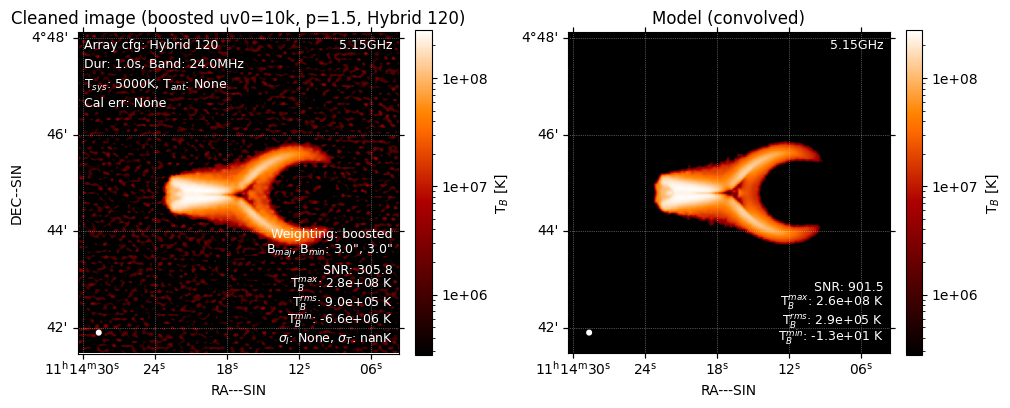

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv010k_p1.5_max3.0_crop00-100.jpg
Copying MS -> FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p2.0.ms
Updated WEIGHT
Updated SIGMA
Boosted tclean restoringbeam for uv0=10k: 3.000arcsec


2026-02-25 19:47:33	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 19:47:33	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 19:47:33	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 19:48:09	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p2.0_image_multiscale.image: 2.767e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p2.0_image_multiscale.image (corners): 9.039e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.648e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.937e+05 K
Plotting both panels with shared 

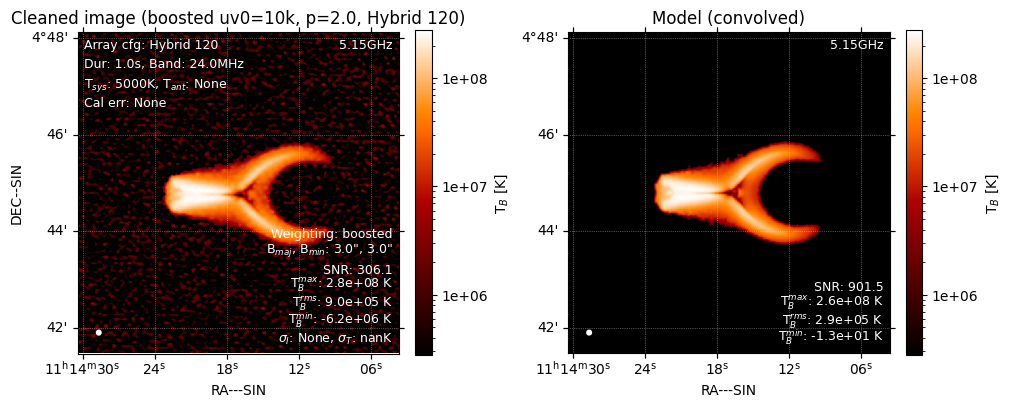

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p2.0_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv010k_p2.0_max3.0_crop00-100.jpg
Copying MS -> FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p1.5.ms
Updated WEIGHT
Updated SIGMA
Boosted tclean restoringbeam for uv0=20k: 1.500arcsec


2026-02-25 19:49:26	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 19:49:26	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 19:49:26	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 19:50:02	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p1.5_image_multiscale.image: 3.322e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p1.5_image_multiscale.image (corners): 2.948e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.052e+05 K
Plotting both panels with shared 

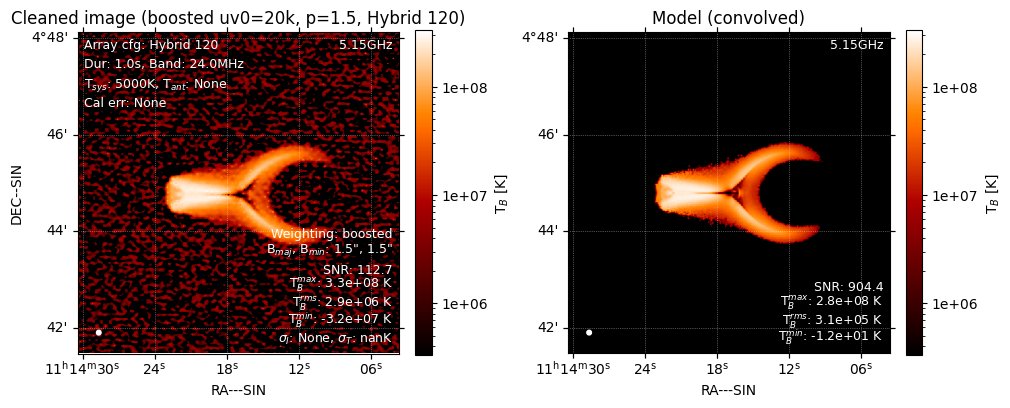

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p1.5_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv020k_p1.5_max3.0_crop00-100.jpg
Copying MS -> FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p2.0.ms
Updated WEIGHT
Updated SIGMA
Boosted tclean restoringbeam for uv0=20k: 1.500arcsec


2026-02-25 19:51:13	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 19:51:13	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 19:51:13	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 19:51:50	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p2.0_image_multiscale.image: 3.356e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p2.0_image_multiscale.image (corners): 2.745e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.052e+05 K
Plotting both panels with shared 

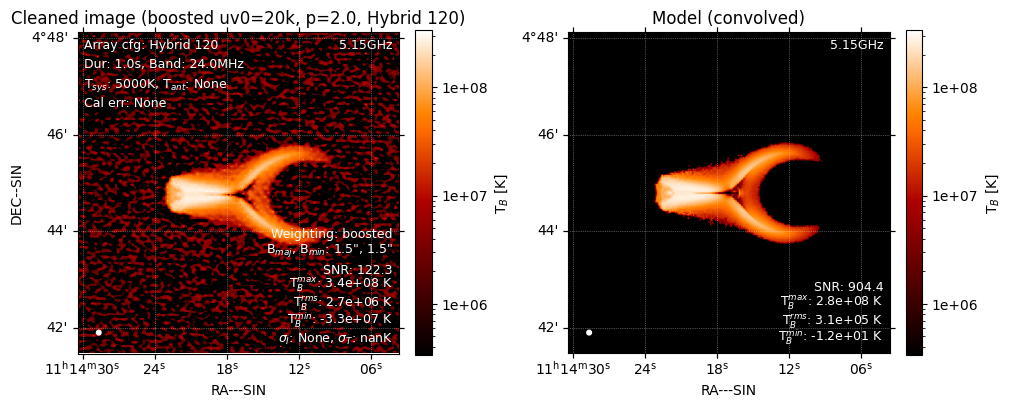

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv020k_p2.0_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv020k_p2.0_max3.0_crop00-100.jpg
Copying MS -> FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p1.5.ms
Updated WEIGHT
Updated SIGMA
Boosted tclean restoringbeam for uv0=30k: 1.000arcsec


2026-02-25 19:53:02	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 19:53:02	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 19:53:02	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 19:53:38	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p1.5_image_multiscale.image: 4.016e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p1.5_image_multiscale.image (corners): 6.232e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.754e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 4.173e+05 K
Plotting both panels with shared 

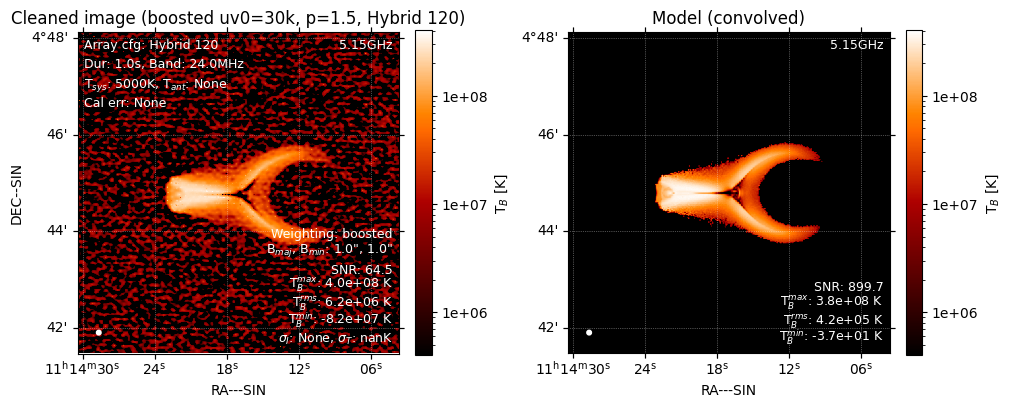

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p1.5_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv030k_p1.5_max3.0_crop00-100.jpg
Copying MS -> FASR/msfiles/flare/fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p2.0.ms
Updated WEIGHT
Updated SIGMA
Boosted tclean restoringbeam for uv0=30k: 1.000arcsec


2026-02-25 19:54:56	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 19:54:56	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 19:54:56	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 19:55:32	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p2.0_image_multiscale.image: 4.017e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p2.0_image_multiscale.image (corners): 6.517e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 3.754e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 4.173e+05 K
Plotting both panels with shared 

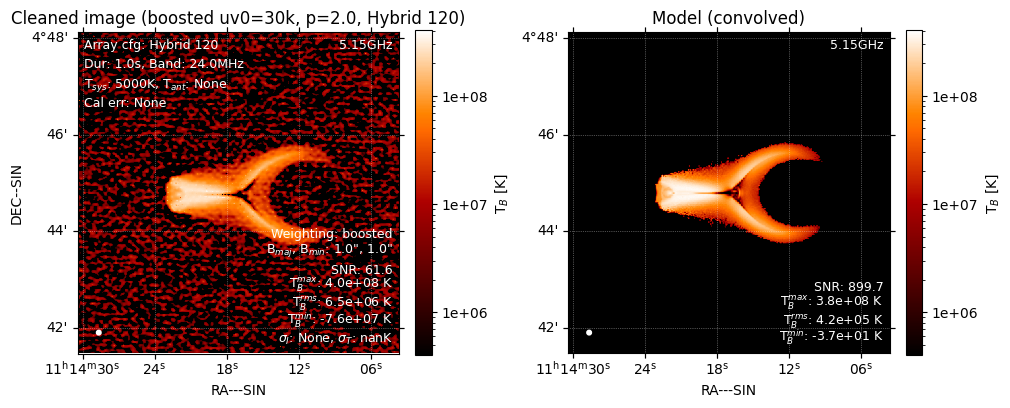

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv030k_p2.0_image_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_boost_uv030k_p2.0_max3.0_crop00-100.jpg
Saved figure: FASR/figs/fig-boost_weighting_curves_fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K.jpg


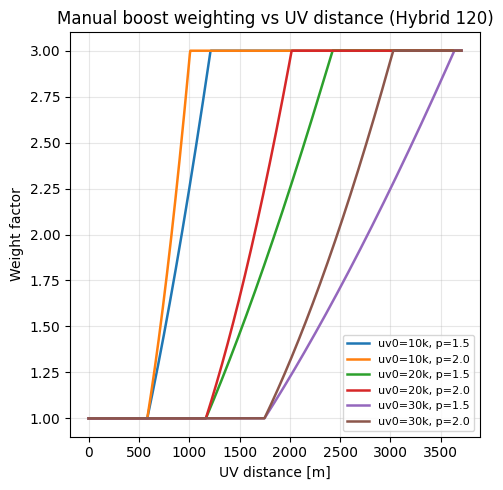

In [76]:
run_superres_products(base_cfg, superres_option='boost', deconvolver_override='multiscale')

2026-02-25 18:44:34	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 18:44:34	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 18:44:34	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 18:46:10	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt10.0k_0.5arcsec_uniform_multiscale.image: 2.387e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt10.0k_0.5arcsec_uniform_multiscale.image (corners): 7.334e+04 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.365e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.339e+05 K
Plotting both panels with s

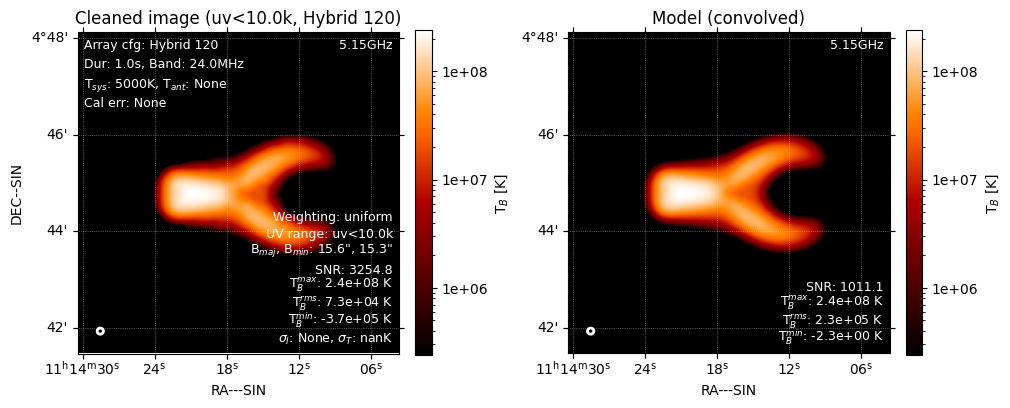

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt10.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt10.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt10.0k_0.5arcsec_uniform_multiscale.image: 6.913e+07 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

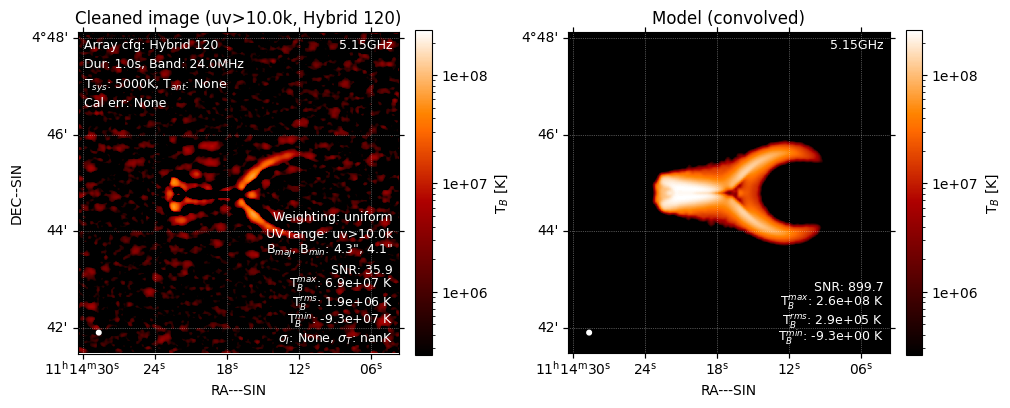

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt10.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt10.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale.image: 4.659e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

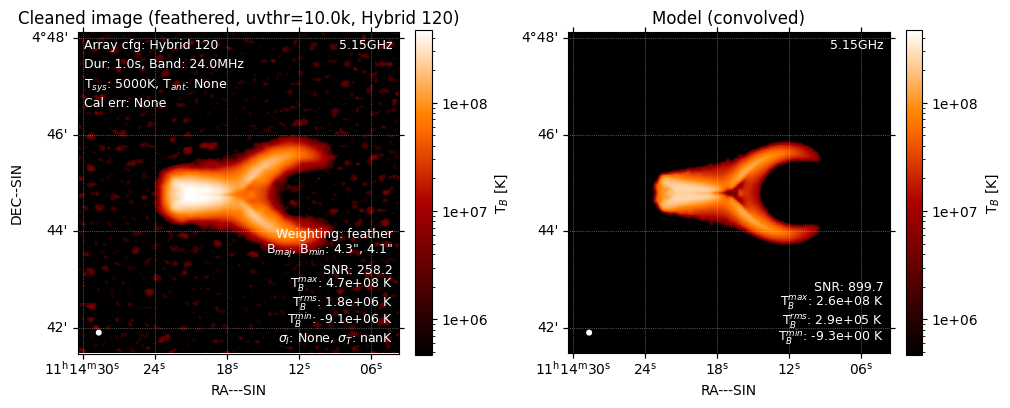

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr10.0k_crop00-100.jpg


2026-02-25 18:47:49	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 18:47:49	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 18:47:49	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 18:49:22	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt15.0k_0.5arcsec_uniform_multiscale.image: 2.471e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt15.0k_0.5arcsec_uniform_multiscale.image (corners): 1.726e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.448e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.541e+05 K
Plotting both panels with s

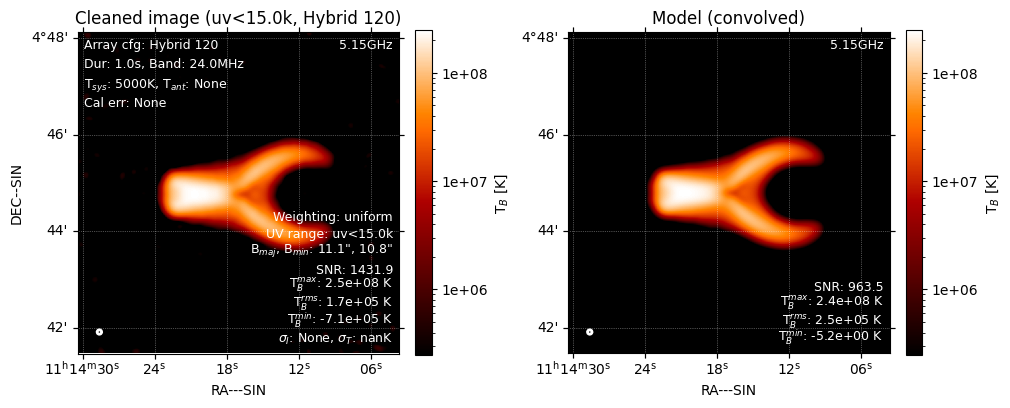

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt15.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt15.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt15.0k_0.5arcsec_uniform_multiscale.image: 1.963e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

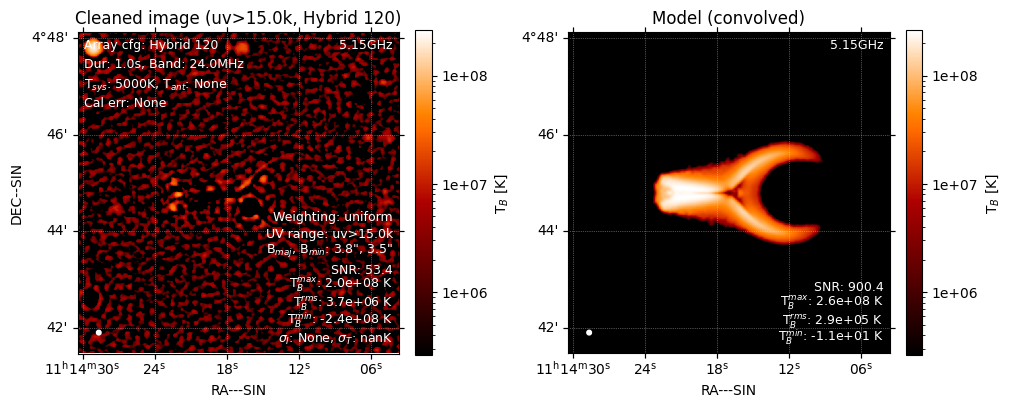

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt15.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt15.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr15.0k_multiscale.image: 4.970e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

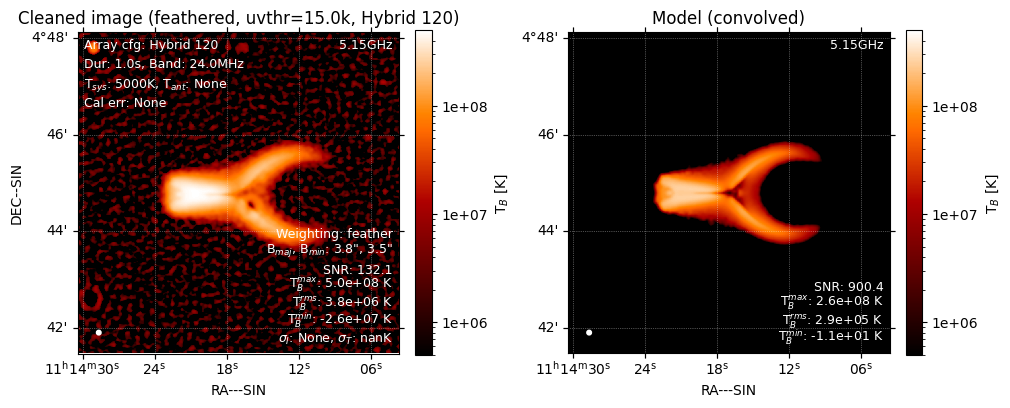

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr15.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr15.0k_crop00-100.jpg


2026-02-25 18:50:28	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 18:50:28	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 18:50:28	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 18:52:03	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt20.0k_0.5arcsec_uniform_multiscale.image: 2.464e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt20.0k_0.5arcsec_uniform_multiscale.image (corners): 3.062e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.462e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.655e+05 K
Plotting both panels with s

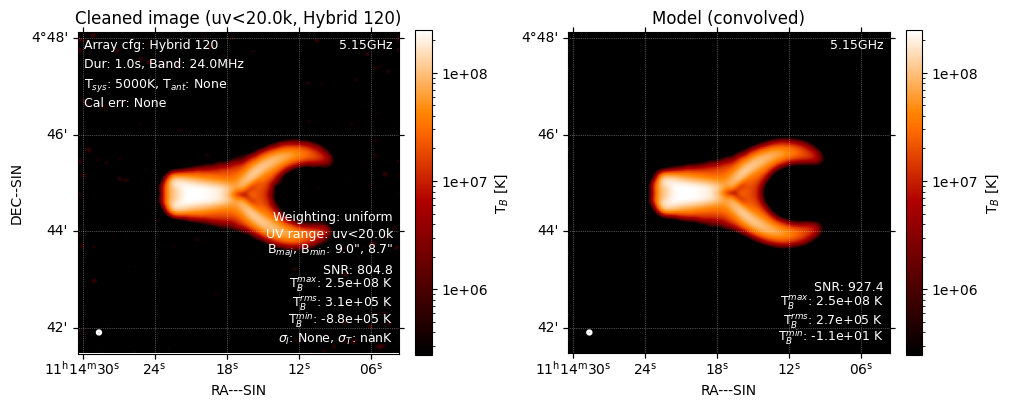

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt20.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt20.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt20.0k_0.5arcsec_uniform_multiscale.image: 1.812e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

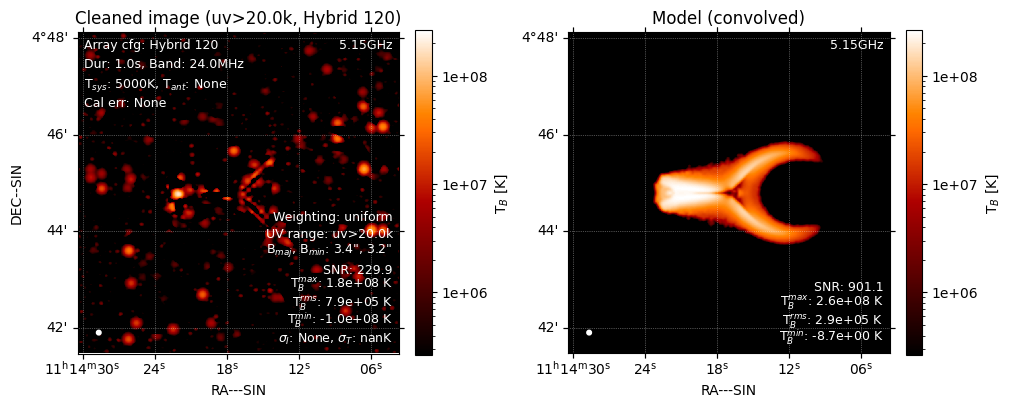

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt20.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt20.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr20.0k_multiscale.image: 4.966e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

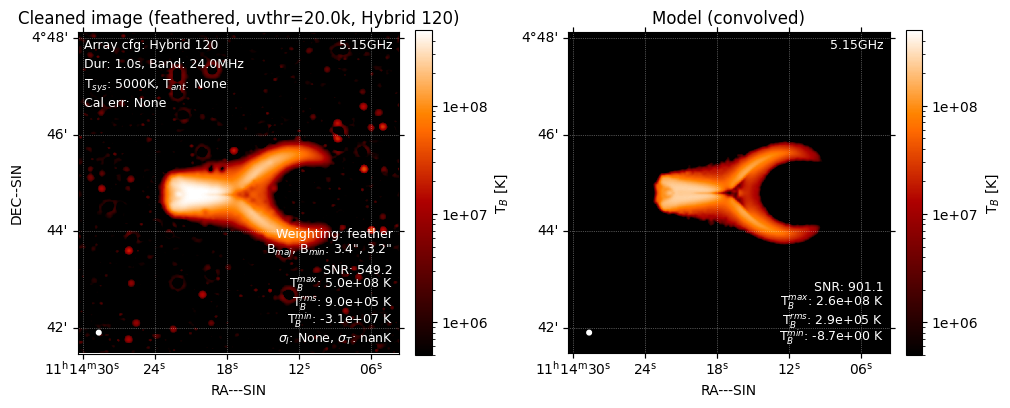

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr20.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr20.0k_crop00-100.jpg


2026-02-25 18:53:53	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 18:53:53	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 18:53:53	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 18:54:26	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt30.0k_0.5arcsec_uniform_multiscale.image: 2.516e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt30.0k_0.5arcsec_uniform_multiscale.image (corners): 2.994e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.514e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.778e+05 K
Plotting both panels with s

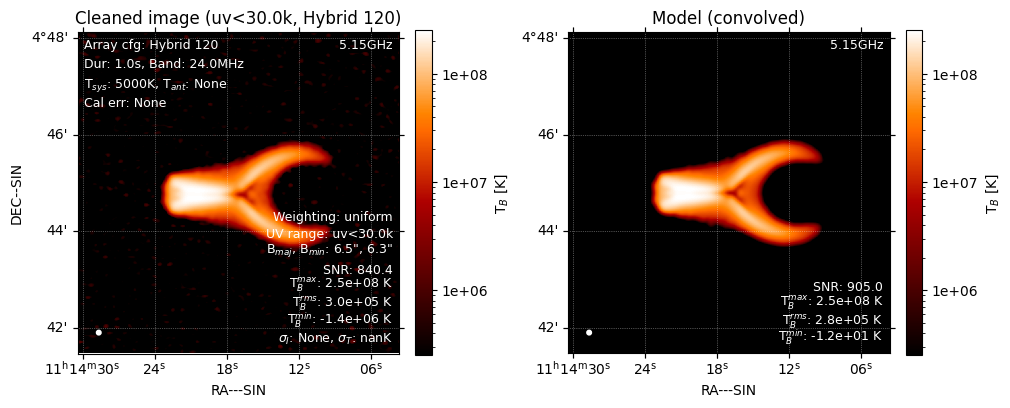

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvlt30.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_short_uvlt30.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt30.0k_0.5arcsec_uniform_multiscale.image: 1.060e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5

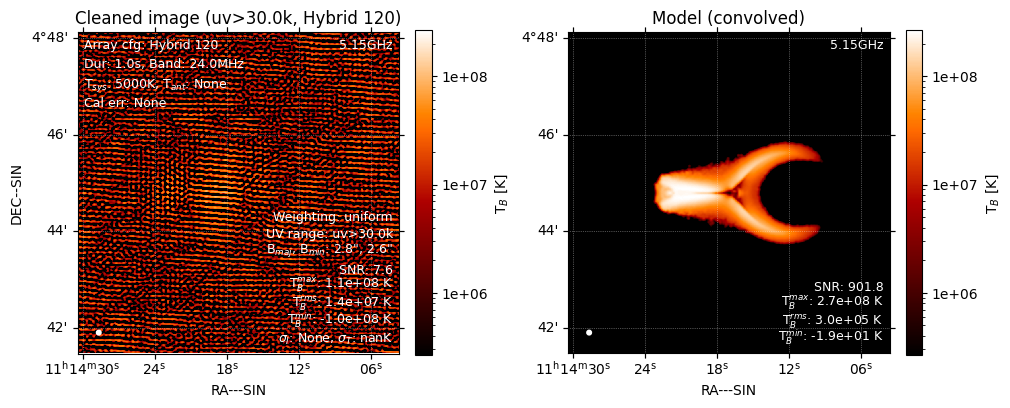

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_uvgt30.0k_0.5arcsec_uniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_long_uvgt30.0k_crop00-100.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr30.0k_multiscale.image: 5.753e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feath

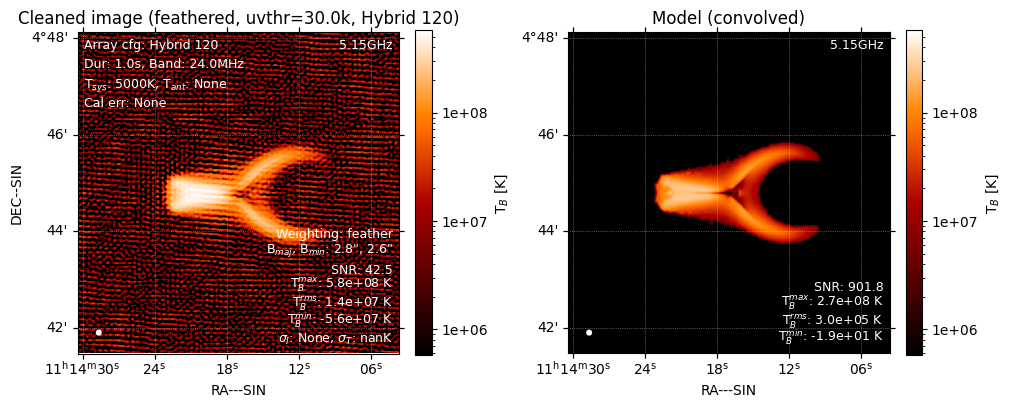

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr30.0k_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_feather_uvthr30.0k_crop00-100.jpg
Saved figure: FASR/figs/fig-uv_density_split_compare_fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K.jpg


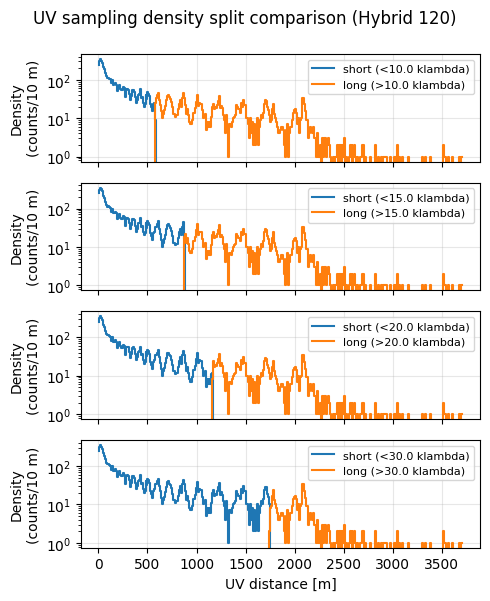

In [60]:
run_superres_products(base_cfg, superres_option='feather', deconvolver_override='multiscale')

2026-02-25 18:57:07	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-25 18:57:07	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-25 18:57:07	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 
2026-02-25 18:57:33	WARN	SDAlgorithmMSClean::takeOneStep (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/c

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_superuniform_multiscale.image: 2.683e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_superuniform_multiscale.image (corners): 1.546e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.651e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 2.941e+05 K
Plotting both panels with shared vmin=2.683e+05 K, vmax=2

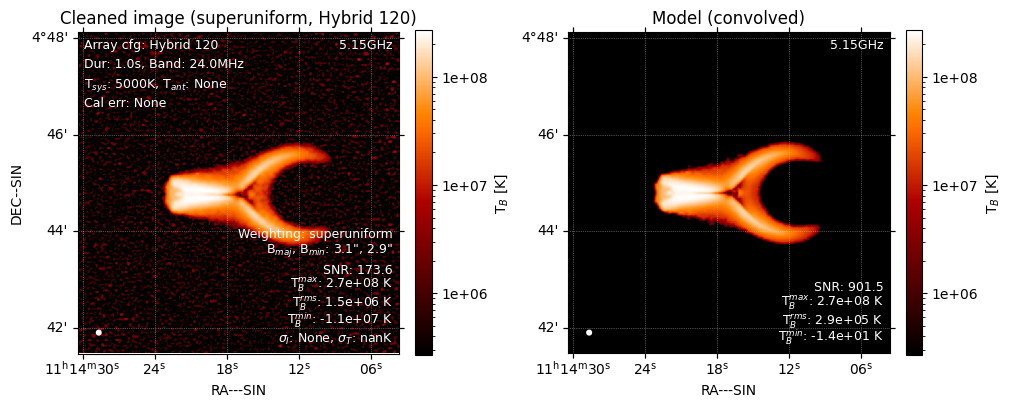

Saved figure: FASR/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_superuniform_multiscale_vs_sep10_flare_cs_model.05.15GHz.I_superuniform_crop00-100.jpg


In [61]:
run_superres_products(base_cfg, superres_option='superuniform', deconvolver_override='multiscale')
# run_superres_products(base_cfg, superres_option=['feather', 'boost'])

In [ ]:
# Super-resolution products for Hybrid 120 + 10 remote (one cfg per call)
run_superres_products(remote_cfg)

In [ ]:
print("Use variable-based paths in flare mode; hardcoded path removed")


Use variable-based paths in flare mode; hardcoded path removed


### make the figures

Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale.image: 4.659e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_feather_uvthr10.0k_multiscale.image (corners): 1.804e+06 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_flare_cs_model.05.15GHz.I.im (off-disk): 3.065e+05 K
Plotting both panels with shared vmin=1.578e+

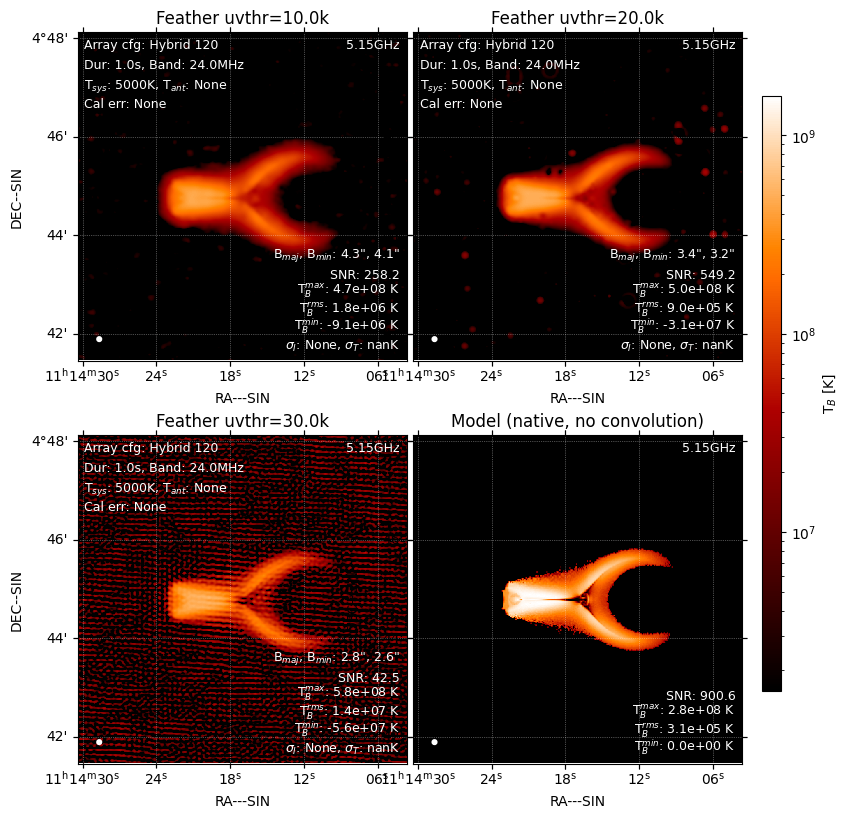

Saved figure: FASR/figs/fig-superres_feather_multiscale_3cases_vs_native_model.jpg
Image1 map obstime: 2017-09-10T19:34:33.660695, Image2 map obstime: 2017-09-10T19:34:33.661
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Peak of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5_image_multiscale.image: 2.759e+08 K
rms of fasr_fasr-a_random_spiral_hybrid_120_flare_05.15GHz_20170910T19UT_dur1s_int1s_noise5000K_wboost_uv010k_p1.5_image_multiscale.image (corners): 9.024e+05 K
Peak of sep10_flare_cs_model.05.15GHz.I.im: 2.760e+08 K
rms of sep10_fla

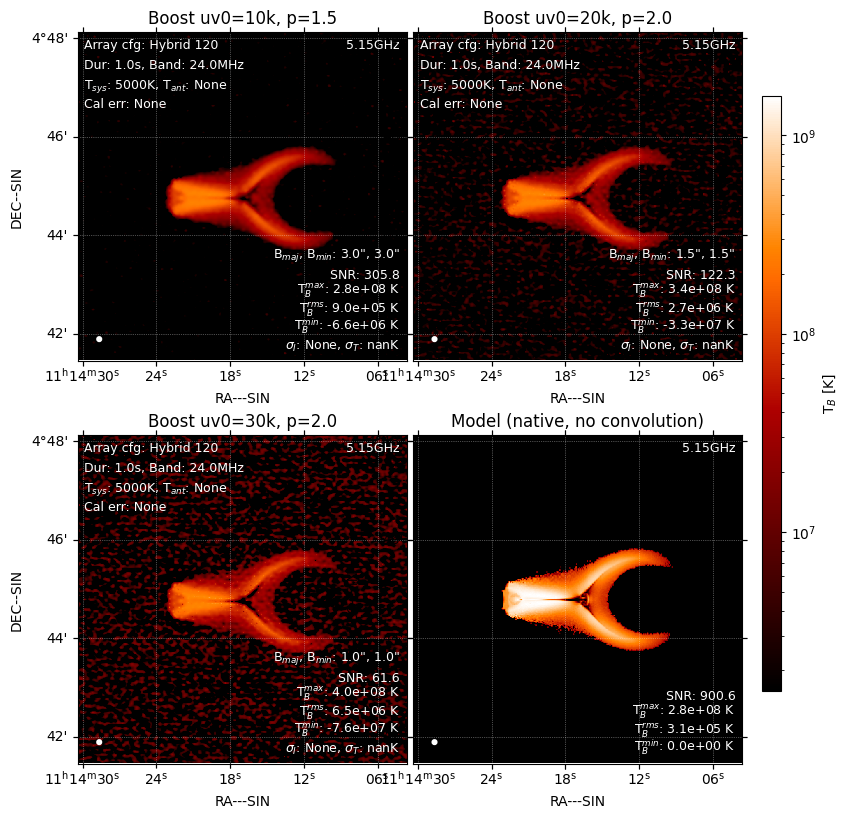

Saved figure: FASR/figs/fig-superres_boost_multiscale_3cases_vs_native_model.jpg


In [100]:
# Manuscript figure assembly from existing products (no clean / no run_superres_products)
# This cell builds composite figures: 3 image results + 1 native model panel in one figure.

from importlib import reload
reload(fss)

model_image_native = _resolve_casa_image_path(model_base)
if model_image_native is None or not os.path.exists(model_image_native):
    raise FileNotFoundError(f'Native model image not found: {model_base}')

# ---- User inputs (three combos each) ----
feather_thresholds_kl = [10.0, 20.0, 30.0]
boost_params = [(10, 1.5), (20, 2.0), (30, 2.0)]
superres_deconvolver_for_manuscript = 'multiscale'

msname_base = _msname_for_cfg(base_cfg)
msfile_base = _msfile_for_cfg(base_cfg)

def _fmt_uv0(uv0):
    u = float(uv0)
    return f'{int(u)}' if abs(u - int(u)) < 1e-9 else str(u)

def _fmt_p(p):
    p = float(p)
    return f'{int(p)}' if abs(p - int(p)) < 1e-9 else str(p)

def _feather_image_path(thr):
    base = f'{msname_base}_feather_uvthr{thr}k_{superres_deconvolver_for_manuscript}'
    return base + '.image'

def _boost_image_path(uv0, power):
    uv_vals = [str(uv0)]
    p_vals = [str(power)]
    try:
        uvf = float(uv0)
        if uvf.is_integer():
            uv_vals.extend([str(int(uvf)), f'{uvf:.1f}'])
    except Exception:
        pass
    try:
        pf = float(power)
        if pf.is_integer():
            p_vals.extend([str(int(pf)), f'{pf:.1f}'])
    except Exception:
        pass

    uv_vals = list(dict.fromkeys(uv_vals))
    p_vals = list(dict.fromkeys(p_vals))

    candidates = []
    for uv_s in uv_vals:
        for p_s in p_vals:
            ms_boost = msfile_base.replace('.ms', f'_wboost_uv0{uv_s}k_p{p_s}.ms')
            candidates.append(ms_boost.replace('.ms', '') + f'_image_{superres_deconvolver_for_manuscript}.image')

    for cpath in candidates:
        if os.path.exists(cpath):
            return cpath
    return candidates[0]

feather_images = [_feather_image_path(t) for t in feather_thresholds_kl]
boost_images = [_boost_image_path(u, p) for u, p in boost_params]

missing_feather = [p for p in feather_images if not os.path.exists(p)]
missing_boost = [p for p in boost_images if not os.path.exists(p)]
if missing_feather:
    raise FileNotFoundError('Missing feather multiscale image(s):\n' + '\n'.join(missing_feather))
if missing_boost:
    raise FileNotFoundError(
        'Missing boost multiscale image(s):\n' + '\n'.join(missing_boost) +
        '\n\nUse existing multiscale boost outputs only, or generate them before running this cell.'
    )

feather_titles = [f'Feather uvthr={thr}k' for thr in feather_thresholds_kl]
boost_titles = [f'Boost uv0={u}k, p={p}' for u, p in boost_params]

fig_feather, _ = fss.plot_two_casa_images_with_convolution_sunpy(
    feather_images,
    model_image_native,
    crop_fraction=crop_fraction,
    reftime=reftime,
    figsize=(8, 8.5),
    panel_titles=feather_titles,
    image_meta={
        **image_meta_common,
        'title': ['Feathering parameter sweep', 'Model (native, no convolution)'],
        'array_config': 'Hybrid 120',
    },
    cmap='hinodexrt',
    vmin=0.1,
    vmax=vmax,
    conv_tag='.unused_native_model',
    overwrite_conv=False,
    convolve_model=False,
    rms_mask_radius=1.2,
    image_rms_corner_size=image_rms_corner_size,
    coord_frame='radec',
    match_fov=True,
    align_model_time_to_image=True,
    north_up=False,
    apply_hpc_p_angle=False,
    anchor_model_wcs_to_image=True,
    use_reftime_for_hpc=True,
)
plt.show()

figname_feather = os.path.join(figdir, 'fig-superres_feather_multiscale_3cases_vs_native_model.jpg')
if os.path.exists(figname_feather) and overwrite_plot:
    os.system('rm -rf ' + figname_feather)
if not os.path.exists(figname_feather):
    fig_feather.savefig(figname_feather, dpi=200)
    print('Saved figure:', figname_feather)

fig_boost, _ = fss.plot_two_casa_images_with_convolution_sunpy(
    boost_images,
    model_image_native,
    crop_fraction=crop_fraction,
    reftime=reftime,
    figsize=(8, 8.5),
    panel_titles=boost_titles,
    image_meta={
        **image_meta_common,
        'title': ['Boost parameter sweep', 'Model (native, no convolution)'],
        'array_config': 'Hybrid 120',
    },
    cmap='hinodexrt',
    vmin=0.1,
    vmax=vmax,
    conv_tag='.unused_native_model',
    overwrite_conv=False,
    convolve_model=False,
    rms_mask_radius=1.2,
    image_rms_corner_size=image_rms_corner_size,
    coord_frame='radec',
    match_fov=True,
    align_model_time_to_image=True,
    north_up=False,
    apply_hpc_p_angle=False,
    anchor_model_wcs_to_image=True,
    use_reftime_for_hpc=True,
)
plt.show()

figname_boost = os.path.join(figdir, 'fig-superres_boost_multiscale_3cases_vs_native_model.jpg')
if os.path.exists(figname_boost) and overwrite_plot:
    os.system('rm -rf ' + figname_boost)
if not os.path.exists(figname_boost):
    fig_boost.savefig(figname_boost, dpi=200)
    print('Saved figure:', figname_boost)


In [ ]:
## next step: add noise esitmate from quiet sun ipynb